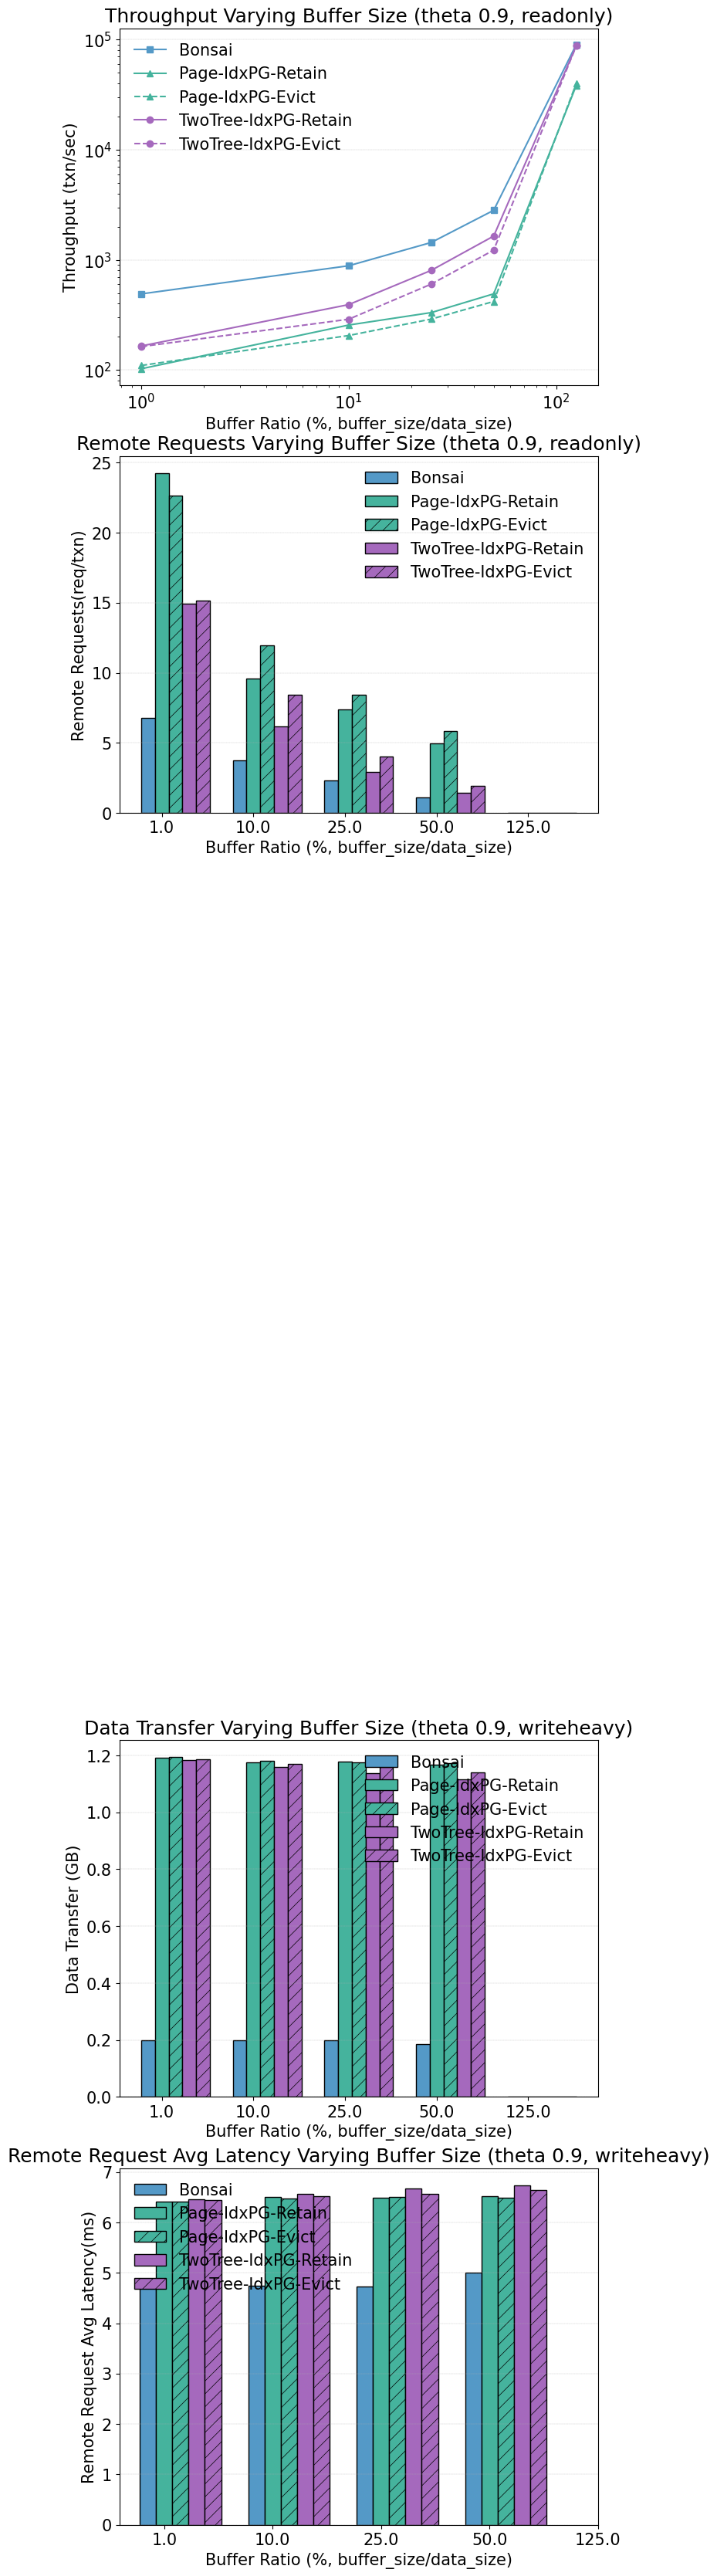

In [8]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
# exp_page = "debug_exp_point_10g_page_fanout250"
exp_page = "exp_point_10g_page_varybuf"
exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict"
exp_tuple = "exp_point_10g_tuple_varybuf"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_varybuf"
exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict"

data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
df_page = df_page.sort_values(by='g_total_buf_sz')


data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict)
df_page_idx_evict = df_page_idx_evict.sort_values(by='g_total_buf_sz')


data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
df_tuple = df_tuple.sort_values(by='g_total_buf_sz')

# data_remote = [json.loads(line) for line in open(datadir + exp_remote)]
# df_remote = pd.DataFrame().from_records(data_remote)
# df_remote = apply_mask(df_remote, [
#     ["g_buf_type", ["eq", "NOBUF"]]
# ])

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt)
df_tt = df_tt.sort_values(by='g_total_buf_sz')


data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='g_total_buf_sz')


# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page_idx_evict["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# print(df_page["throughput_txn_per_sec"])
# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt_idx_evict["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(100, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Buffer Size (theta 0.9, readonly)")


index = np.arange(len(df_tuple["g_total_buf_sz"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 2)


ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_xscale('log')
ax1.set_title("Remote Requests Varying Buffer Size (theta 0.9, readonly)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)

ax1 = fig.add_subplot(6, 1, 5)

ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/1000000.0, bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        (df_page["misses_"])*8/1000000.0, bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Data Transfer (GB)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


ax1 = fig.add_subplot(6, 1, 6)


ax1.bar(index + 1 * bar_width, 
        df_tuple["remote_io_time_ms"]*1.0/df_tuple["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        (df_page["remote_io_time_ms"])*1.0/df_page["remote_rds_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index[:-1] + 3 * bar_width, 
        # (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        ((df_page_idx_evict["remote_io_time_ms"])*1.0/df_page_idx_evict["remote_rds_"])[:-1], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        # (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
         (df_tt["remote_io_time_ms"])*1.0/df_tt["remote_rds_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        # (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        ((df_tt_idx_evict["remote_io_time_ms"])*1.0/df_tt_idx_evict["remote_rds_"]),bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Request Avg Latency(ms)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
ax1.set_title("Remote Request Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


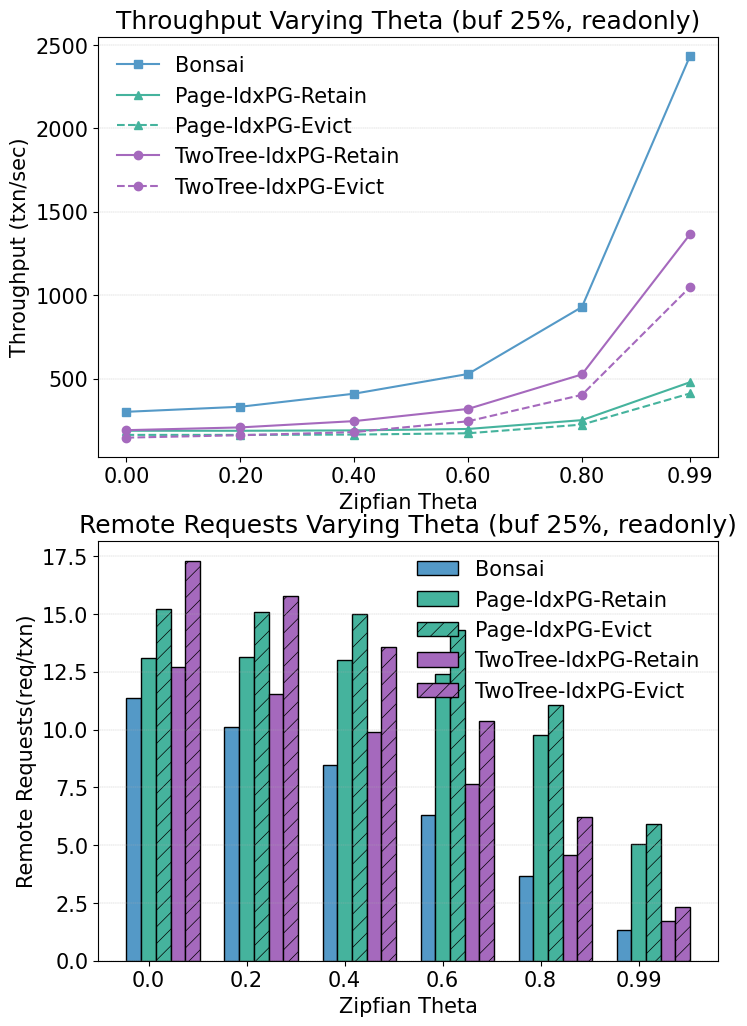

In [6]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","zipf_theta_"]
datadir = "../output/"
# exp_page = "debug_exp_point_10g_page_fanout250"
exp_page = "exp_point_10g_page_unihotspot"
exp_page_idx_evict = "exp_point_10g_page_unihotspot_idx_evict"
exp_tuple = "exp_point_10g_tuple_unihotspot"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_unihotspot"
exp_twotree_idx_evict = "exp_point_10g_twotree_unihotspot_idx_evict"

data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
df_page = df_page.sort_values(by='zipf_theta_')


data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict)
df_page_idx_evict = df_page_idx_evict.sort_values(by='zipf_theta_')


data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
df_tuple = df_tuple.sort_values(by='zipf_theta_')

# data_remote = [json.loads(line) for line in open(datadir + exp_remote)]
# df_remote = pd.DataFrame().from_records(data_remote)
# df_remote = apply_mask(df_remote, [
#     ["g_buf_type", ["eq", "NOBUF"]]
# ])

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt)
df_tt = df_tt.sort_values(by='zipf_theta_')


data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='zipf_theta_')


# print(df_tuple)
fig = plt.figure(figsize=(8, 12))

# fig, ax = plt.subplots()
ax = fig.add_subplot(2, 1, 1)


ax.plot(df_tuple["zipf_theta_"], 
        df_tuple["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_page["zipf_theta_"], 
        df_page["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Retain")

# # Annotate each data point with its corresponding value
# for i in range(len(df_page["zipf_theta_"])):
#     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["zipf_theta_"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["zipf_theta_"], 
        df_page_idx_evict["throughput_txn_per_sec"],
        color=line_colors["GREEN"],
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')

# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["zipf_theta_"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["zipf_theta_"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["zipf_theta_"], 
        df_tt["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["zipf_theta_"], 
        df_tt_idx_evict["throughput_txn_per_sec"],
        color=line_colors["PURPLE"],
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
# ax.set_ylim(0, max_throughput)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["zipf_theta_"])
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Theta (buf 25%, readonly)")


index = np.arange(len(df_tuple["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(2, 1, 2)

ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["GREEN"],
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=line_colors["PURPLE"],
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Zipfian Theta")
ax1.set_title("Remote Requests Varying Theta (buf 25%, readonly)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)




In [ ]:
import numpy as np
from scipy.stats import zipfian

# first parameter: the rank of key
# second parameter: theta
# third parameter: total number of keys
zipfian.cdf(5000000, 0.99, 10000000)

0.9550785969536522

In [29]:
import numpy as np
from scipy.stats import zipfian

zipfian.cdf(2500000, 0.99, 10000000)

0.9163284587187417

In [28]:
zipfian.cdf(2500000, 1, 10000000)

0.9169650579889799

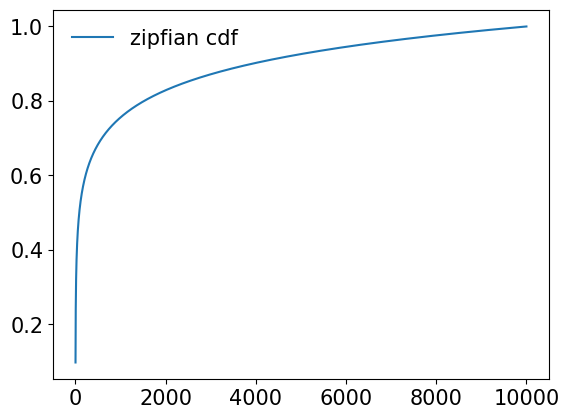

In [27]:
import numpy as np
from scipy.stats import zipfian
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
a, n = 0.99, 10000
x = np.arange(1, n+1)


# ax.plot(x, zipfian.pmf(x, a, n),label='zipfian pmf')
ax.plot(x, zipfian.cdf(x, a, n),label='zipfian cdf')
# ax.vlines(x, 0, zipfian.pmf(x, a, n), colors='b', lw=1, alpha=0.5)

# rv = zipfian(a, n)
# ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
#         label='frozen pmf')
ax.legend(loc='best', frameon=False)
plt.show()

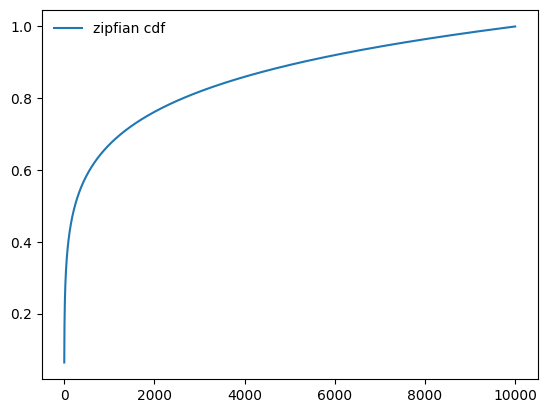

In [1]:
import numpy as np
from scipy.stats import zipfian
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
a, n = 0.9, 10000
x = np.arange(1, n+1)


# ax.plot(x, zipfian.pmf(x, a, n),label='zipfian pmf')
ax.plot(x, zipfian.cdf(x, a, n),label='zipfian cdf')
# ax.vlines(x, 0, zipfian.pmf(x, a, n), colors='b', lw=1, alpha=0.5)

# rv = zipfian(a, n)
# ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
#         label='frozen pmf')
ax.legend(loc='best', frameon=False)
plt.show()